In [1]:
import pandas as pd 

In [2]:
# IBM Plex Sans font setup via helper (no network)
import sys, os
sys.path.insert(0, '/share/pierson/matt/UAIR/notebooks')
from font_utils import load_ibm_plex_sans
import matplotlib.pyplot as plt

PAPER_PATH = os.getenv('PAPER_PATH')

try:
    loaded_path = load_ibm_plex_sans()
    print(f'IBM Plex Sans font loaded from {loaded_path}')
except Exception as e:
    print(f'Could not load IBM Plex Sans, using sans-serif fallback: {e}')
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']


RESULTS_US_PATH = '/share/pierson/matt/UAIR/outputs/2025-11-12/domain_agnostic_ai_us/full_event_pipeline_general_ai/outputs'
RESULTS_GLOBAL_PATH = '/share/pierson/matt/UAIR/outputs/2025-11-13/domain_agnostic_ai/full_event_pipeline_general_ai/outputs'


IBM Plex Sans font loaded from /share/pierson/matt/UAIR/assets/fonts/ibm-plex-sans/fonts/complete/ttf/IBMPlexSans-Regular.ttf


In [3]:
# Load global and US EU AI Act classification results
classify_eu_act_global = pd.read_parquet(RESULTS_GLOBAL_PATH + '/classify_eu_ai_act/classify_eu_ai_act_results.parquet')
classify_eu_act_us = pd.read_parquet(RESULTS_US_PATH + '/classify_eu_ai_act/classify_eu_ai_act_results.parquet')

print(f'Global dataset: {len(classify_eu_act_global)} articles')
print(f'US dataset: {len(classify_eu_act_us)} articles')

# Combine datasets
# Note: US data doesn't have deployment_domain, so we'll handle that separately
classify_eu_act_all = pd.concat([classify_eu_act_global, classify_eu_act_us], ignore_index=True)
print(f'Combined dataset: {len(classify_eu_act_all)} articles')

classify_eu_act_all.info()

Global dataset: 2764 articles
US dataset: 227 articles
Combined dataset: 2991 articles
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2991 entries, 0 to 2990
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   article_id            2991 non-null   object 
 1   article_path          2991 non-null   object 
 2   article_text          2991 non-null   object 
 3   core_tuple_verified   2991 non-null   bool   
 4   country               2991 non-null   object 
 5   eu_valid_input_count  2991 non-null   int64  
 6   keyword_match_count   2991 non-null   int64  
 7   matched_keywords      2991 non-null   object 
 8   relevant_keyword      2991 non-null   bool   
 9   too_vague_to_process  2991 non-null   bool   
 10  year                  2991 non-null   object 
 11  eu_ai_desc            2114 non-null   object 
 12  eu_ai_label           2114 non-null   object 
 13  eu_ai_relevant_text   2114 non-null 

In [ ]:
# Load decompose_nbl outputs for both US and global datasets
decompose_nbl_global = pd.read_parquet(RESULTS_GLOBAL_PATH + '/decompose_nbl/tuples.parquet')









uv run --python .venv/bin/python scripts/sidewalk_network/04_filter_segments.py \
  --intermediate-dir data/intermediate \
  --out-dir data/intermediate \
  --cpu-fallback
decompose_nbl_us = pd.read_parquet(RESULTS_US_PATH + '/decompose_nbl/tuples.parquet')

print(f'Global decompose_nbl: {len(decompose_nbl_global)} rows')
print(f'US decompose_nbl: {len(decompose_nbl_us)} rows')

# Combine decompose_nbl datasets
decompose_nbl_all = pd.concat([decompose_nbl_global, decompose_nbl_us], ignore_index=True)
print(f'Combined decompose_nbl: {len(decompose_nbl_all)} rows')

# Merge with classify_eu_act_all to get deployment_domain and other fields
classify_eu_act_all = classify_eu_act_all.merge(
    decompose_nbl_all[['article_id', 'deployment_domain', 'deployment_purpose', 'deployment_capability', 
                       'identity_of_ai_deployer', 'identity_of_ai_subject', 'identity_of_ai_developer',
                       'location_of_ai_deployer', 'location_of_ai_subject', 'date_and_time_of_event',
                       'list_of_harms_that_occurred', 'list_of_risks_that_occurred', 'list_of_benefits_that_occurred']],
    on='article_id',
    how='left'
)

print(f'After merge: {len(classify_eu_act_all)} articles')
print(f'Articles with deployment_domain: {classify_eu_act_all["deployment_domain"].notna().sum()}')


Global decompose_nbl: 8033 rows
US decompose_nbl: 568 rows
Combined decompose_nbl: 8601 rows
After merge: 2991 articles
Articles with deployment_domain: 2991


In [5]:
# Filter to articles with eu_ai_desc (required for analysis)
print(f'Before filtering: {len(classify_eu_act_all)} articles')
classify_eu_act_all.dropna(subset=['eu_ai_desc'], inplace=True)
print(f'After filtering (with eu_ai_desc): {len(classify_eu_act_all)} articles')

Before filtering: 2991 articles
After filtering (with eu_ai_desc): 2114 articles


In [6]:
classify_eu_act_all.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2114 entries, 0 to 2936
Data columns (total 33 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   article_id                      2114 non-null   object 
 1   article_path                    2114 non-null   object 
 2   article_text                    2114 non-null   object 
 3   core_tuple_verified             2114 non-null   bool   
 4   country                         2114 non-null   object 
 5   eu_valid_input_count            2114 non-null   int64  
 6   keyword_match_count             2114 non-null   int64  
 7   matched_keywords                2114 non-null   object 
 8   relevant_keyword                2114 non-null   bool   
 9   too_vague_to_process            2114 non-null   bool   
 10  year                            2114 non-null   object 
 11  eu_ai_desc                      2114 non-null   object 
 12  eu_ai_label                     2114 no

In [7]:
# Overall distribution of eu_ai_label across combined dataset (Global + US)
print('Overall eu_ai_label distribution:')
print(classify_eu_act_all['eu_ai_label'].value_counts())
print(f'\nTotal articles with eu_ai_label: {len(classify_eu_act_all)}')

# Distribution by country (showing US vs others)
print('\nDistribution by country (top 10):')
print(classify_eu_act_all['country'].value_counts().head(10))

# US articles eu_ai_label distribution
us_articles = classify_eu_act_all[classify_eu_act_all['country'] == 'us']
if len(us_articles) > 0:
    print(f'\nUS articles eu_ai_label distribution ({len(us_articles)} articles):')
    print(us_articles['eu_ai_label'].value_counts())

Overall eu_ai_label distribution:
eu_ai_label
Limited or Low Risk    1576
High Risk               399
Prohibited              139
Name: count, dtype: int64

Total articles with eu_ai_label: 2114

Distribution by country (top 10):
country
us    172
fi    150
lu     91
vn     90
th     80
co     79
be     68
sg     66
hk     64
au     58
Name: count, dtype: int64

US articles eu_ai_label distribution (172 articles):
eu_ai_label
Limited or Low Risk    115
High Risk               40
Prohibited              17
Name: count, dtype: int64


In [8]:
# Group by deployment_domain, sort descending by size, and get the top 10
# Note: US articles don't have deployment_domain, so they're excluded from this analysis
classify_eu_act_with_domain = classify_eu_act_all.dropna(subset=['deployment_domain'])
print(f'Articles with deployment_domain: {len(classify_eu_act_with_domain)} (out of {len(classify_eu_act_all)} total)')
classify_eu_act_with_domain.groupby('deployment_domain').size().sort_values(ascending=False)

Articles with deployment_domain: 2114 (out of 2114 total)


deployment_domain
Health and Healthcare                                             200
Transport and Logistics                                           189
Media and Communication                                           168
Education and vocational training                                 136
Finance and Investment                                            131
Government Services and Administration                            130
Energy                                                            125
Social Media                                                      117
Military and Defense                                              108
International Law Enforcement and Cooperation                      68
Agriculture and Farming                                            64
Entrepreneurship                                                   64
Urban Planning                                                     63
Human-Computer Interaction                                         62
Sm

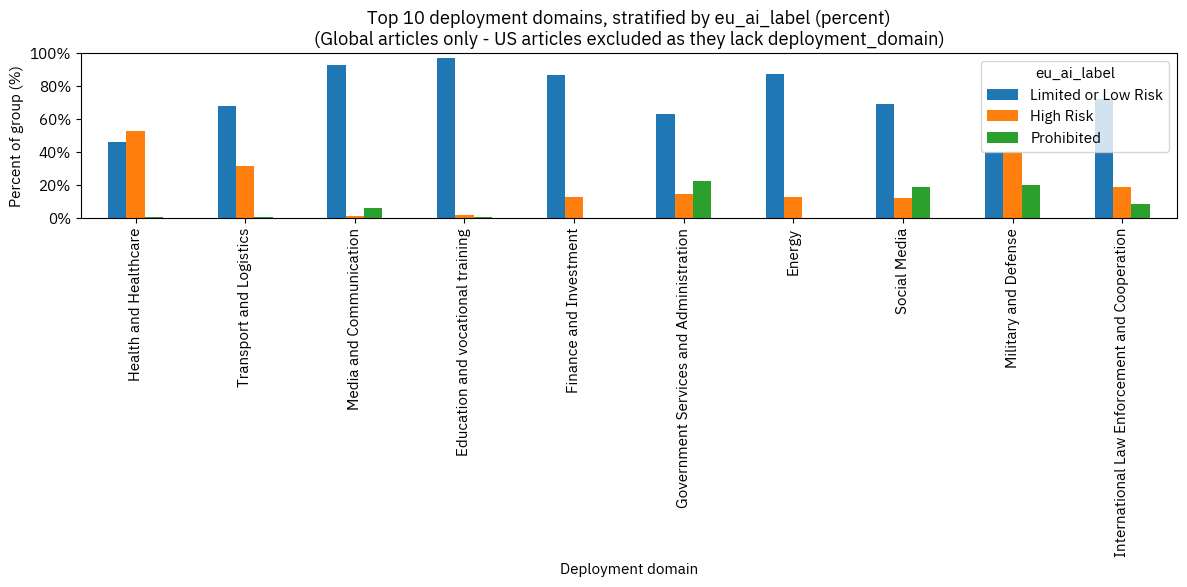

In [9]:
# Make a joint histogram of the top 10 stratified by eu_ai_label
# Using only articles with deployment_domain (excludes US articles)

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Use the filtered dataset with deployment_domain
# compute top 10 deployment domains
_top_domains = classify_eu_act_with_domain['deployment_domain'].value_counts().head(10).index
_df_top = classify_eu_act_with_domain[classify_eu_act_with_domain['deployment_domain'].isin(_top_domains)]

# counts by domain and label
_counts = (
    _df_top.groupby(['deployment_domain', 'eu_ai_label'])
           .size()
           .unstack(fill_value=0)
           .reindex(_top_domains)
)

# convert to row-wise percentages
_pct = _counts.div(_counts.sum(axis=1), axis=0).fillna(0) * 100

# order bars (columns) as Limited, High, Prohibited
_label_order = ['Limited or Low Risk', 'High Risk', 'Prohibited']
_ordered_cols = [c for c in _label_order if c in _pct.columns] + [c for c in _pct.columns if c not in _label_order]
_pct = _pct.reindex(columns=_ordered_cols)

fig, ax = plt.subplots(figsize=(12, 6))
_pct.plot(kind='bar', ax=ax, stacked=False)
ax.set_xlabel('Deployment domain')
ax.set_ylabel('Percent of group (%)')
ax.set_ylim(0, 100)
ax.yaxis.set_major_formatter(PercentFormatter(100))
ax.set_title('Top 10 deployment domains, stratified by eu_ai_label (percent)\n(Global articles only - US articles excluded as they lack deployment_domain)')
ax.legend(title='eu_ai_label')
plt.tight_layout()

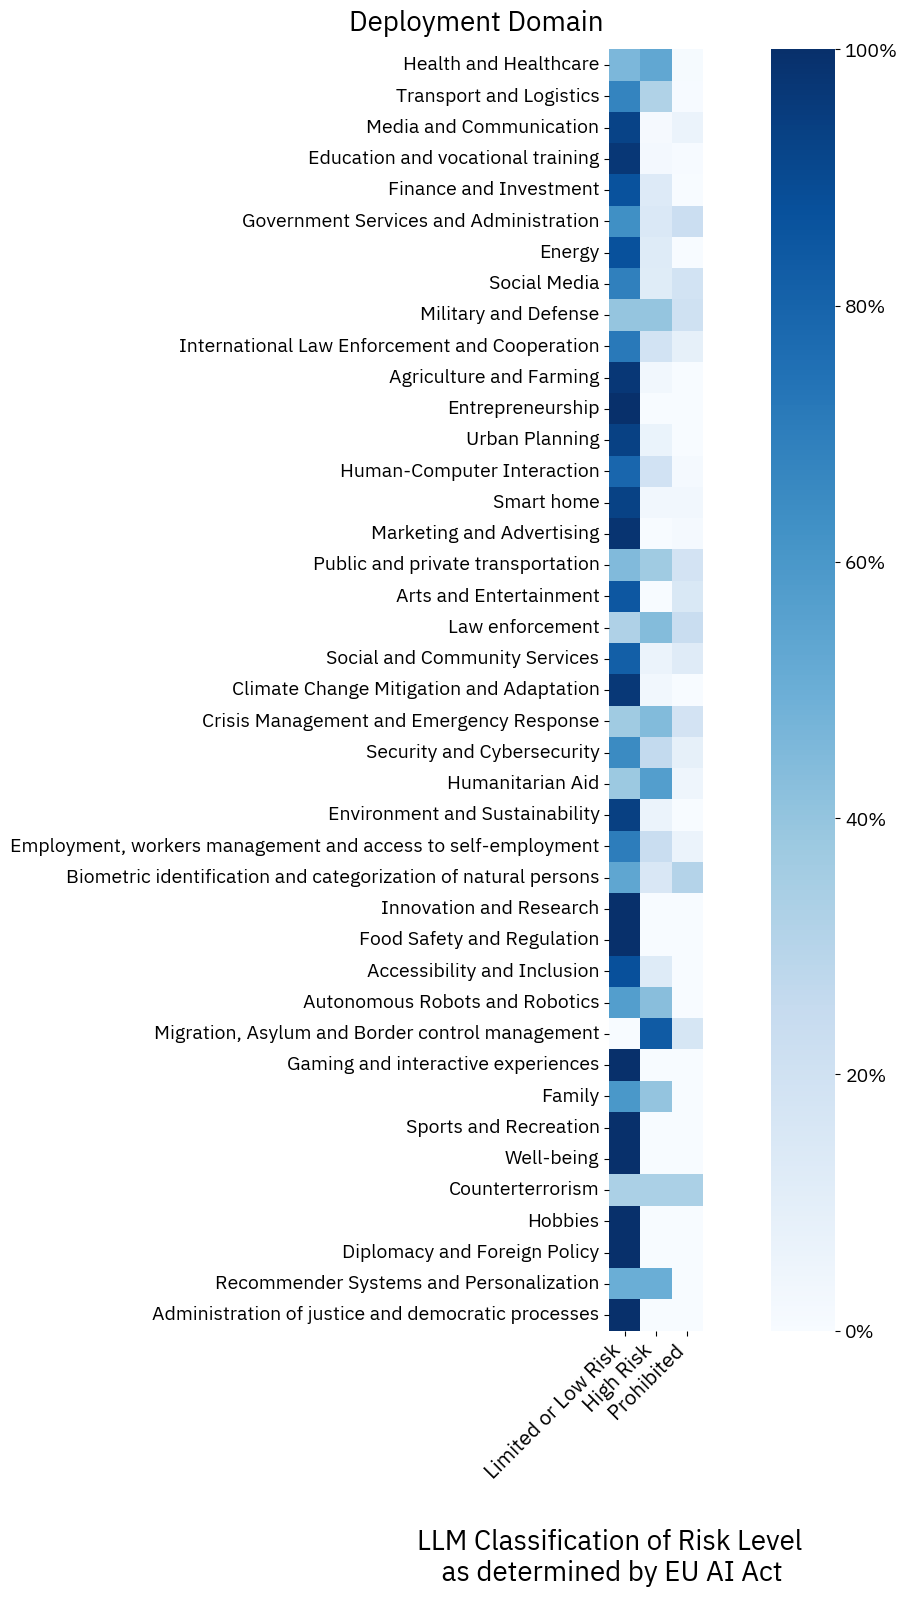

In [10]:
# Alternative heatmap: all domains x eu_ai_label as % of domain total
# Using only articles with deployment_domain (excludes US articles)
try:
    import seaborn as sns
except Exception:
    sns = None
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# Use the filtered dataset with deployment_domain
# counts by domain and label across all domains
_heat_counts = (
    classify_eu_act_with_domain.groupby(['deployment_domain', 'eu_ai_label'])
                       .size()
                       .unstack(fill_value=0)
)
# order domains by total count descending
_domain_order = _heat_counts.sum(axis=1).sort_values(ascending=False).index
_heat_counts = _heat_counts.reindex(_domain_order)

# reorder label columns as Limited, High, Prohibited
_label_order = ['Limited or Low Risk', 'High Risk', 'Prohibited']
_ordered_cols = [c for c in _label_order if c in _heat_counts.columns] + [c for c in _heat_counts.columns if c not in _label_order]
_heat_counts = _heat_counts.reindex(columns=_ordered_cols)

# row-wise percentages
_heat_pct = _heat_counts.div(_heat_counts.sum(axis=1).replace(0, 1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, max(16, 0.3 * len(_heat_pct))))
if sns is not None:
    hm = sns.heatmap(_heat_pct, cmap='Blues', cbar=True, square=True)
    # format colorbar as percent
    cbar = hm.collections[0].colorbar
    cbar.formatter = PercentFormatter(100)
    cbar.update_ticks()
    cbar.ax.tick_params(labelsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=15)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right', fontsize=14)


ax.set_xlabel('')
ax.set_ylabel('')
ax.text(-.06, 1.01, 'Deployment Domain', ha='right', va='bottom', transform=ax.transAxes, fontsize=20)
ax.text(0.0, -.2, 'LLM Classification of Risk Level\n as determined by EU AI Act', ha='center', va='bottom', transform=ax.transAxes, fontsize=20)
plt.tight_layout()

# Save as PDF
plt.savefig(os.path.join(PAPER_PATH, 'figures', 'eu_ai_act_classifications_heatmap.pdf'), dpi=300, bbox_inches='tight')
# Save as PNG
plt.savefig(os.path.join(PAPER_PATH, 'figures', 'eu_ai_act_classifications_heatmap.png'), dpi=300, bbox_inches='tight')
